In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

In [15]:
df_raw = pd.read_excel('dados_aula08_sarimax.xlsx')

df_raw.head()

,data,vendas,temperatura,feriado
0,2020-01-06,458.431716,20.993428,1
1,2020-01-13,689.511394,20.928838,0
2,2020-01-20,610.337570,23.688534,0
3,2020-01-27,646.711686,26.592109,0
4,2020-02-03,644.334682,24.178925,0


In [ ]:
df = df_raw.copy()   


,data,vendas,temperatura,feriado
0,2020-01-06,458.431716,20.993428,1
1,2020-01-13,689.511394,20.928838,0
2,2020-01-20,610.337570,23.688534,0
3,2020-01-27,646.711686,26.592109,0
4,2020-02-03,644.334682,24.178925,0


In [17]:
df.corr()

,data,vendas,temperatura,feriado
data,1.000000,0.659958,-0.162814,-0.058291
vendas,0.659958,1.000000,0.557969,-0.232790
temperatura,-0.162814,0.557969,1.000000,-0.001548
feriado,-0.058291,-0.232790,-0.001548,1.000000


In [18]:
x = df[['temperatura', 'feriado']]

vif = pd.DataFrame()

vif["variavel"] = x.columns

vif["VIF"] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]

print(vif)

      variavel       VIF
0  temperatura  1.034657
1      feriado  1.034657


In [19]:
#StandardScaler
scaler = StandardScaler()

In [20]:
df.set_index('data', inplace=True)

In [21]:
#Div treino teste
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

In [22]:
#Padronização dos dados
#Fit aplica só no treino, transform aplica no treino e teste
train_data_scaled = scaler.fit_transform(train_data)
test_data_scaled = scaler.transform(test_data)


In [23]:
print(f"Treino: {len(train_data)} obs | Teste: {len(test_data)} obs")
print(f"X_train média: {train_data_scaled.mean(axis=0).round(4)}  (deve ser 0)")
print(f"X_train std  : {train_data_scaled.std(axis=0).round(4)}  (deve ser 1)")

Treino: 166 obs | Teste: 42 obs
X_train média: [0. 0. 0.]  (deve ser 0)
X_train std  : [1. 1. 1.]  (deve ser 1)


In [26]:
modelo_base = SARIMAX(
    train_data['vendas'], # <-- Alteração aqui
    order=(0, 1, 2),
    seasonal_order=(0, 1, 1, 52),
).fit(disp=False)

print(f"BIC sem exog: {modelo_base.bic:.2f}")
fc_base = modelo_base.get_forecast(steps=42)
mae_base = mean_absolute_error(test_data['vendas'], fc_base.predicted_mean)
print(f"MAE sem exog: {mae_base:.2f}")

BIC sem exog: 1209.15
MAE sem exog: 28.34


In [27]:
# Treinando o modelo com variáveis exógenas
modelo_exog = SARIMAX(
    train_data['vendas'], # Apenas a variável alvo (vendas)
    exog=train_data[['temperatura', 'feriado']], # Suas variáveis exógenas de treino
    order=(0, 1, 2),
    seasonal_order=(0, 1, 1, 52),
).fit(disp=False)

# 1. Print do BIC com as variáveis exógenas
print(f"BIC com exog: {modelo_exog.bic:.2f}")

# 2. Gerando a previsão (ATENÇÃO: tem que passar o exog do teste aqui!)
# Assumindo que seu 'h' (horizonte) e os dados de teste já estão definidos
fc_exog = modelo_exog.get_forecast(steps=42, exog=test_data[['temperatura', 'feriado']])

# 3. Calculando o erro (MAE)
mae_exog = mean_absolute_error(test_data['vendas'], fc_exog.predicted_mean)

# 4. Print do MAE com exog
print(f"MAE com exog: {mae_exog:.2f}")

BIC com exog: 1183.62
MAE com exog: 26.78


In [28]:
print(modelo_exog.summary())

                                      SARIMAX Results                                       
Dep. Variable:                               vendas   No. Observations:                  166
Model:             SARIMAX(0, 1, 2)x(0, 1, [1], 52)   Log Likelihood                -577.626
Date:                              Mon, 03 Aug 2026   AIC                           1167.252
Time:                                      08:49:12   BIC                           1183.616
Sample:                                  01-06-2020   HQIC                          1173.892
                                       - 03-06-2023                                         
Covariance Type:                                opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temperatura     4.1777      1.561      2.677      0.007       1.119       7.236
feriado      -13

MAE com exog: 26.78 | MAE sem exog: 28.34
Ganho: 5.5%


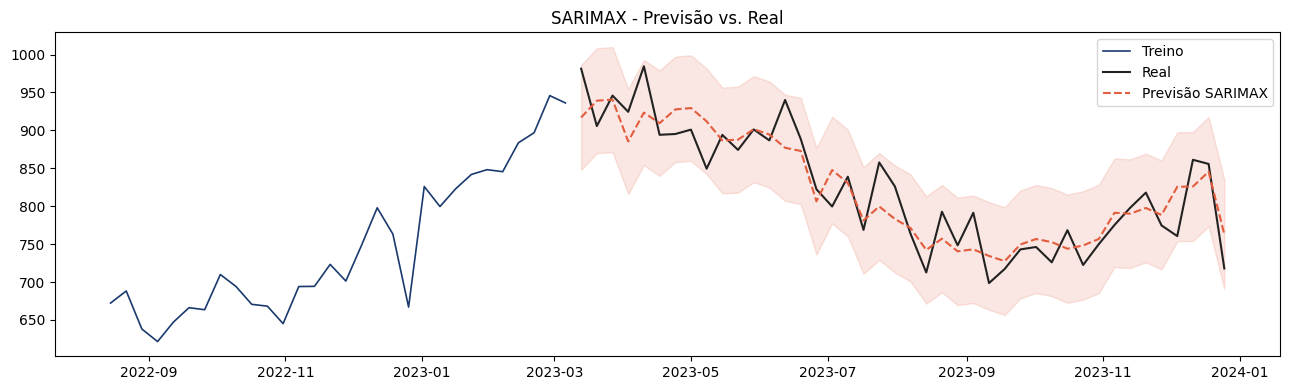

In [29]:
fc_exog = modelo_exog.get_forecast(steps=42, exog=test_data[['temperatura', 'feriado']])
pred    = fc_exog.predicted_mean
ci      = fc_exog.conf_int(alpha=0.05)

mae_exog = mean_absolute_error(test_data['vendas'], pred)
print(f"MAE com exog: {mae_exog:.2f} | MAE sem exog: {mae_base:.2f}")
print(f"Ganho: {(mae_base - mae_exog)/mae_base*100:.1f}%")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_data.index[-30:], train_data['vendas'][-30:], label='Treino', color='#1a3a6e', linewidth=1.2)
ax.plot(test_data.index, test_data['vendas'], label='Real', color='#222', linewidth=1.5)
ax.plot(pred.index, pred, '--', label='Previsão SARIMAX', color='#e25c3e', linewidth=1.5)
ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.15, color='#e25c3e')
ax.set_title('SARIMAX - Previsão vs. Real')
ax.legend()
plt.tight_layout()
plt.show()

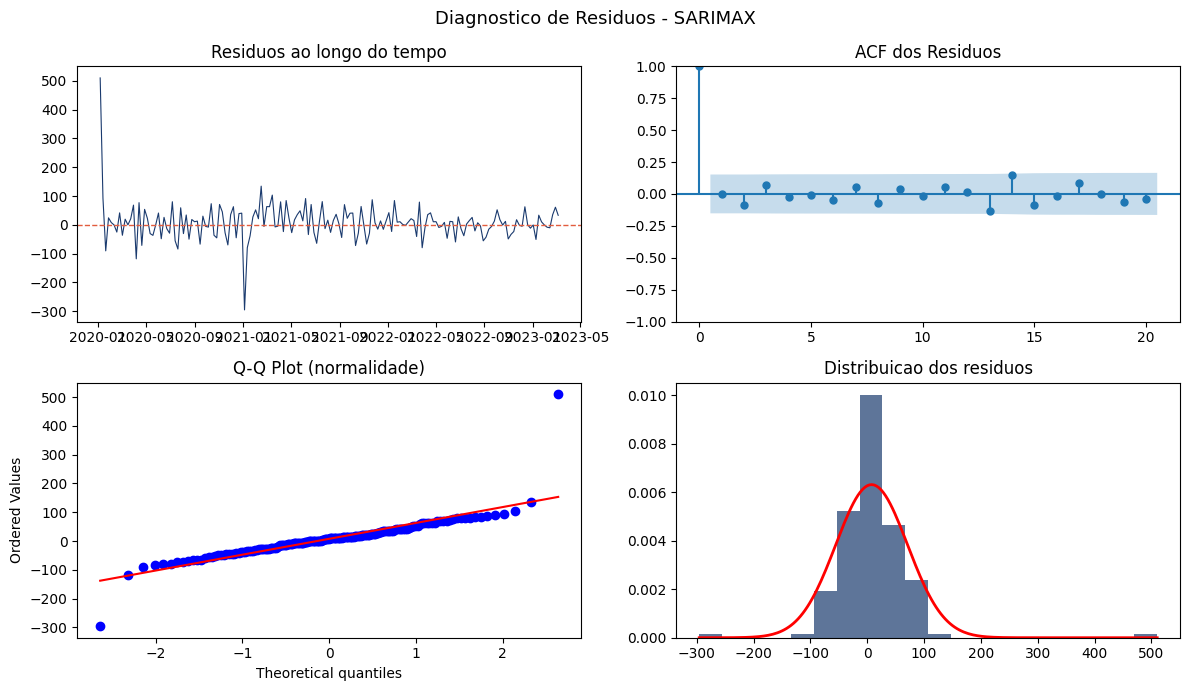

Ljung-Box (H0: sem autocorrelacao nos residuos):
    lb_stat  lb_pvalue
1    0.0031     0.9557
2    1.2058     0.5472
3    1.9633     0.5801
4    2.0819     0.7207
5    2.0977     0.8355
6    2.4465     0.8744
7    3.0209     0.8831
8    3.9003     0.8660
9    4.1883     0.8986
10   4.2492     0.9354
p > 0.05 em todos os lags: True -> residuos OK


In [30]:
import scipy.stats as stats
from statsmodels.stats.diagnostic import acorr_ljungbox
resid = modelo_exog.resid.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].plot(resid.index, resid, color="#1a3a6e", linewidth=0.8)
axes[0, 0].axhline(0, color="#e25c3e", linewidth=1, linestyle="--")
axes[0, 0].set_title("Residuos ao longo do tempo")

plot_acf(resid, lags=20, ax=axes[0, 1], title="ACF dos Residuos")

stats.probplot(resid, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot (normalidade)")

axes[1, 1].hist(resid, bins=20, density=True, color="#1a3a6e", alpha=0.7)
x = np.linspace(resid.min(), resid.max(), 200)
from scipy.stats import norm
axes[1, 1].plot(x, norm.pdf(x, resid.mean(), resid.std()), "r-", linewidth=2)
axes[1, 1].set_title("Distribuicao dos residuos")

plt.suptitle("Diagnostico de Residuos - SARIMAX", fontsize=13)
plt.tight_layout()
plt.show()

# Ljung-Box H0 residuos sem autocorrelacao
lb = acorr_ljungbox(resid, lags=10, return_df=True)
print("Ljung-Box (H0: sem autocorrelacao nos residuos):")
print(lb[["lb_stat", "lb_pvalue"]].round(4))
all_ok = (lb["lb_pvalue"] > 0.05).all()
status = "OK" if all_ok else "com autocorrelacao"
print(f"p > 0.05 em todos os lags: {all_ok} -> residuos {status}")